In [7]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.patches as mpatches
import pandas as pd

from xseas import SeasonDetect, X_labels


import matplotlib as mpl
from pathlib import Path
from matplotlib.lines import Line2D

# Imposta stile globale
mpl.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

In [8]:
import yaml

with open('paths.local.yaml', 'r') as file:
    paths = yaml.safe_load(file)

FIGURES_DIR = Path(paths['FIGURES_DIR'])
SUPP_FIGURES_DIR = Path(paths['SUPP_FIGURES_DIR'])
WORKING_FOLDER = Path(paths['WORKING_FOLDER'])

In [9]:
# Ensure figures directory exists
# FIGURES_DIR.mkdir(exist_ok=True)

# Define key paths
SHAPEFILES_PATH = WORKING_FOLDER / 'shapefiles'
REFERENCES_PATH = WORKING_FOLDER / 'references'
CLUSTERING_PATH = WORKING_FOLDER / 'clusterings'
CONFIG_FILE = 'four_seas_all_vars.yaml'

In [10]:
boundary = gpd.read_file(SHAPEFILES_PATH / 'boundary.gpkg')
s = SeasonDetect(WORKING_FOLDER, 'four_seas_all_vars.yaml')

# Load evaluation dataset on ERA5


✅ Using existing XSeas project at: /Users/jacopograssi/Documents/XSeas/working_folder
⚠️  Recommended key missing: parameters_projections


In [11]:
def load_and_clip(name):
    bnd = gpd.read_file(SHAPEFILES_PATH / f'{name}.gpkg')

    all_models = []
    for model in s.CMIP6_models:
        if os.path.exists(os.path.join(s.perceptron_path, 'evaluation', f'eval_{s.name}_{model}.nc')):
            dataset_eval = xr.open_dataset(os.path.join(s.perceptron_path, 'evaluation', f'eval_{s.name}_{model}.nc'))
            all_models.append(dataset_eval)

    all_models = xr.concat(all_models, dim='model',coords='minimal', compat='override')
    all_models = all_models.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    all_models.rio.write_crs("epsg:4326", inplace=True);
    all_models = all_models.rio.clip(bnd.geometry.apply(mapping))
    return all_models


def load_and_clip_eval(name):
    bnd = gpd.read_file(SHAPEFILES_PATH / f'{name}.gpkg')

    eval_ds = xr.open_dataset(s.perceptron_path / 'evaluation' / f'eval_{s.name}_ERA5.nc')

    eval_ds = eval_ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    eval_ds.rio.write_crs("epsg:4326", inplace=True);
    eval_ds = eval_ds.rio.clip(bnd.geometry.apply(mapping))
    return eval_ds

Average F1 score for HKK in a) winter : 0.7229370179175917 + 0.04727650245936262
Average F1 score for him in a) winter : 0.7443923599141004 + 0.06796002592578373
Average F1 score for central_india in a) winter : 0.815593033407506 + 0.06969077692111988
Average F1 score for southwest_india in a) winter : 0.8542680803381294 + 0.03489484479934099
Average F1 score for HKK in b) pre-monsoon : 0.5272491752947007 + 0.075757390021612
Average F1 score for him in b) pre-monsoon : 0.613376755439872 + 0.08102723659233341
Average F1 score for central_india in b) pre-monsoon : 0.7441999010258785 + 0.0958909430764317
Average F1 score for southwest_india in b) pre-monsoon : 0.8214580086172115 + 0.030957800456494395
Average F1 score for HKK in c) monsoon : 0.5624516116115932 + 0.09410061111816959
Average F1 score for him in c) monsoon : 0.7560983178332487 + 0.10201653143299448
Average F1 score for central_india in c) monsoon : 0.8556987088269854 + 0.09441450069667377
Average F1 score for southwest_india

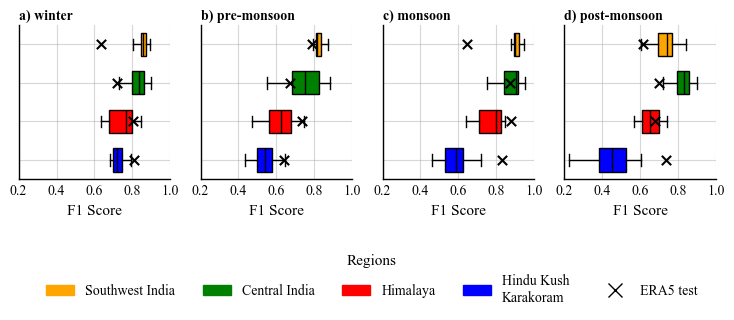

In [15]:
names = ['HKK', 'him', 'central_india','southwest_india']
colors = ['b', 'r' ,'g' ,'orange']

fig, ax = plt.subplots(1,4, figsize=(9, 2), sharex=True, sharey=False, dpi=100)

for idx, season in enumerate(['a) winter', 'b) pre-monsoon', 'c) monsoon', 'd) post-monsoon']):
    all_data = []
    for name, col, pos in zip(names, colors, [0,1,2,3]):
        all_models = load_and_clip(name)
        eval_ds = load_and_clip_eval(name).f1.sel(cluster=idx).mean(['lat','lon'])
        data = all_models.sel(cluster=idx).mean(['lat','lon'])
        data = 2 * (data.precision * data.recall) / (data.precision + data.recall)
        all_data.append(data.values)
        ax[idx].boxplot(
            data.values.flatten(),
            positions=[pos],                    
            vert=False,
            patch_artist=True,
            widths=0.6,
            showfliers=False,
            boxprops=dict(facecolor=col, color='black', lw=1, edgecolor='black'),
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', color='black', markersize=2, alpha=0.5),
        )

        # Add point with the eval_ds_value
        ax[idx].scatter(
            eval_ds.values, pos,
            color='black',
            marker='x',
            s=45,
            label='ERA5',
            zorder=5
        )

        print('Average F1 score for', name, 'in', season, ':', data.values.mean(), '+', data.values.std())

    all_data = np.array(all_data)
    models = all_models.model.values.tolist()

    ax[idx].set_yticks(np.arange(0,4,1))
    ax[idx].text(0.0, 1.1, season, transform=ax[idx].transAxes, fontsize=10, fontweight='bold', va='top', ha='left')


legend_patches = [
    mpatches.Patch(color='orange',  label='Southwest India'),
    mpatches.Patch(color='g',  label='Central India'),
    mpatches.Patch(color='r',  label='Himalaya'),
    mpatches.Patch(color='b',  label='Hindu Kush \nKarakoram'),
    Line2D([0], [0], marker='x', color='black', linestyle='None', markersize=10, label='ERA5 test')
]

for a_x in ax.flatten():
    a_x.set_xlim(0.2,1)
    a_x.spines['top'].set_visible(False)
    a_x.spines['right'].set_visible(False)
    a_x.grid(True, alpha=0.5)
    a_x.set_xticks(np.arange(0.2, 1.1, 0.2))
    a_x.set_xticklabels(np.arange(0.2, 1.1, 0.2).round(1), fontsize=10)
    a_x.tick_params(axis='both', which='both', length=0)
    a_x.set_yticklabels([])

for i in range(4):
    ax[i].set_xlabel('F1 Score')

ax[1].legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(-1.1, -0.4), fontsize=10, ncol=5, frameon=False, title='Regions')

# Save figure
f1_path = FIGURES_DIR / 'f1_scores.png'
# fig.savefig(f1_path, dpi=300, bbox_inches='tight', transparent=True)